In [1]:
%matplotlib inline

import math
import time
import numpy as np
import torch
from matplotlib_inline import backend_inline
import matplotlib.pyplot as plt

In [2]:
n = 10000
a = torch.ones(n)
b = torch.ones(n)
a, b, a.shape, b.shape

(tensor([1., 1., 1.,  ..., 1., 1., 1.]),
 tensor([1., 1., 1.,  ..., 1., 1., 1.]),
 torch.Size([10000]),
 torch.Size([10000]))

In [3]:
class Timer:
    """记录多次运行时间"""
    def __init__(self):
        self.times = []
        self.start()

    def start(self):
        """启动计时器"""
        self.tik = time.time()

    def stop(self):
        """停止计时器并将列表记录在列表中"""
        self.times.append(time.time() - self.tik)
        return self.times[-1]

    def avgA(self):
        """返回平均时间"""
        return sum(self.times) / len(self.times)

    def sum(self):
        """返回时间总和"""
        return sum(self.times)

    def cumsum(self):
        """返回累计时间"""
        return np.array(self.times).cumsum().tolist()
        

In [4]:
c = torch.zeros(n)
timer = Timer()
for i in range(n):
    c[i] = a[i] + b[i]
print(f'{timer.stop():.6f}s')

0.203325s


In [5]:
timer.start()
d = a + b
print(f'{timer.stop():.6f}s')

0.000000s


In [6]:
def normal(x, mu, sigma):
    p = 1 / math.sqrt(2 * math.pi * sigma**2)
    return p * np.exp(-0.5 / sigma ** 2 * (x - mu)**2)

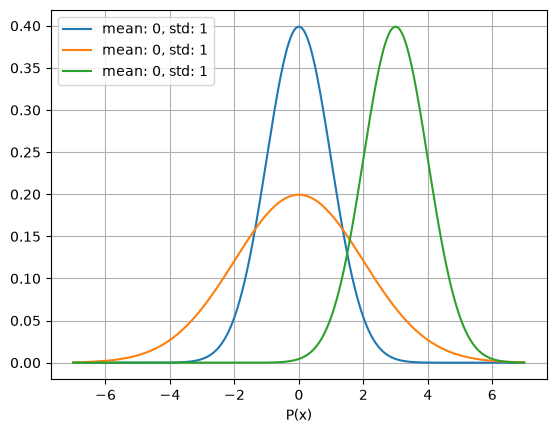

In [7]:
x = np.arange(-7, 7, 0.01)
params = [(0, 1), (0, 2), (3, 1)]
fig, ax = plt.subplots()
ax.set_xlabel("x")
ax.set_xlabel("P(x)")
legend =[f"mean: {mu}, std: {sigma}" for mu, sigma in params]
ax.grid()
i=0
for mu, sigma in params:
    ax.plot(x, normal(x, mu, sigma), label=legend[0])
    ax.legend()
    i=i+1


In [8]:
# 练习
x = torch.randint(-50, 50, (100, )).float() + torch.randn(100)
b = torch.tensor(0., requires_grad=True)
lr = 0.01
y = ((x - b)**2).sum()
print(y)

for i in range(100000):
    y = ((x - b)**2).sum()
    y.backward()
    with torch.no_grad():
        b -= lr * b.grad
    b.grad.zero_()
b, y


tensor(76242.5156, grad_fn=<SumBackward0>)


(tensor(4.7684e-07, requires_grad=True),
 tensor(76242.5156, grad_fn=<SumBackward0>))